# SSURGO Soil Data&mdash;Weather Station Comparison

This notebook queries the USDA SSURGA database for soil data near an installed weather station.

The SSURGO data is organized into a SQL database. Soil data parameters available as fields in the SSURGO tables are described in [this pdf](https://sdmdataaccess.sc.egov.usda.gov/documents/TablesAndColumnsReport.pdf).

A useful tutorial on querying the SSURGO data in R can be found [here](https://ncss-tech.github.io/AQP/soilDB/SDA-tutorial.html), and a useful Python script is [here](https://gitlab.msu.edu/-/snippets/649).

1) Load dependencies

In [61]:
import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd
import requests
import shapely.wkt as wkt
import shapely.geometry as geom
import xml.etree.ElementTree as ET

2) Sample location

Define the sample region.

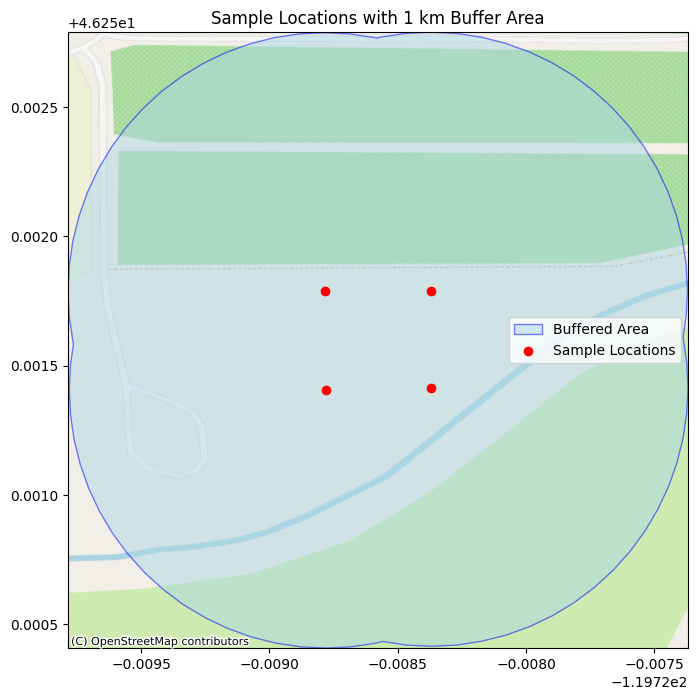

In [62]:
sample_location = [
    { "latitude": 46.251788, "longitude": -119.728785 },
    { "latitude": 46.251790, "longitude": -119.728371 },
    { "latitude": 46.251407, "longitude": -119.728780 },
    { "latitude": 46.251414, "longitude": -119.728369 },
]

# Define a WKT polygon with a 0.1 km buffer around the sample location
buffer_distance = 0.001  # Approx. 0.1 km in degrees
points = [geom.Point(loc["longitude"], loc["latitude"]) for loc in sample_location]
multi_point = geom.MultiPoint(points)
buffered_area = multi_point.buffer(buffer_distance)
wkt_polygon = buffered_area.wkt

# Plot the sample area and buffer region with state/county boundaries using OpenStreetMap
fig, ax = plt.subplots(figsize=(8, 8))
x, y = buffered_area.exterior.xy
ax.fill(x, y, alpha=0.5, fc='lightblue', ec='blue', label='Buffered Area')
point_coords = [(point.x, point.y) for point in multi_point.geoms]
ax.scatter([x for x, y in point_coords], [y for x, y in point_coords], color='red', label='Sample Locations')

# Set axis limits to the buffered area extent
ax.set_xlim(min(x), max(x))
ax.set_ylim(min(y), max(y))

# Specify Coordinate Reference System (CRS) as EPSG:4326 (WGS84 latitude/longitude)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Sample Locations with 1 km Buffer Area')
ax.legend()
plt.show()

3) XML -> DataFrame

Create a function that will convert XML output from the SSURGO SQL query to a Pandas DataFrame.

In [63]:
def xml_to_dataframe(xml_string: str) -> pd.DataFrame:
    """Parse XML string and convert Table elements to a pandas DataFrame."""
    root = ET.fromstring(xml_string)
    # Find all Table elements
    tables = root.findall(".//Table")
    
    if not tables:
        return pd.DataFrame()
    
    data = []
    for table in tables:
        row = {}
        for child in table:
            # Extract tag and text content
            tag = child.tag
            text = child.text
            row[tag] = text
        data.append(row)
    
    return pd.DataFrame(data)

4) Validate region

Create a function that tests to ensure the target region intersects at least one USDA Map Unit.

In [64]:
def get_mapunit_geometry(polygon_wkt: str) -> str:
    """Return geometries for any mapunits within the given polygon WKT."""
    url = "https://sdmdataaccess.nrcs.usda.gov/Tabular/SDMTabularService/post.rest"
    
    query = f"""
    SELECT
        mapunit.mukey,
        mapunit.muname,
        mapunit.musym,
        mupolygon.mupolygongeo.STAsText() as geom
    FROM mapunit
    INNER JOIN mupolygon ON mapunit.mukey = mupolygon.mukey
    WHERE mupolygon.mupolygongeo.STIntersects(
            geometry::STGeomFromText('{polygon_wkt}', 4326)
    ) = 1
    """
    
    payload = {"query": query}
    response = requests.post(url, data=payload)
    
    return response.text

5) Plot Map Units

Plot the intersecting map units.

Found 4 map units within the buffered area.


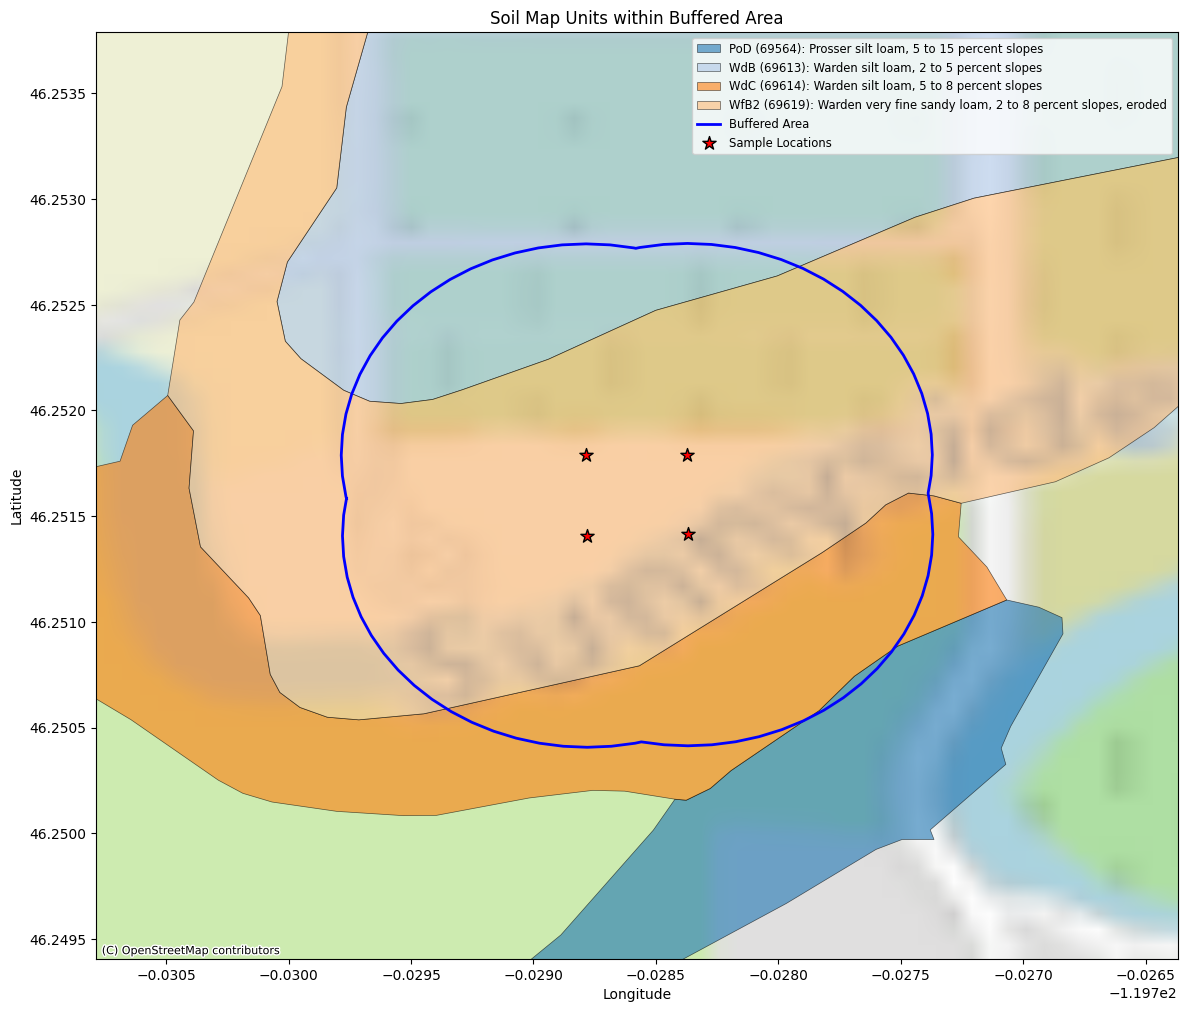

In [65]:
df_geom = xml_to_dataframe(get_mapunit_geometry(wkt_polygon))
print(f"Found {len(df_geom)} map units within the buffered area.")

df_geom['geometry'] = df_geom['geom'].apply(lambda x: wkt.loads(x) if x else None)

# Create a figure with map units colored by type
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each map unit polygon
colors = plt.cm.tab20(range(len(df_geom)))
for idx, row in df_geom.iterrows():
    if row['geometry']:
        if row['geometry'].geom_type == 'Polygon':
            x, y = row['geometry'].exterior.xy
            ax.fill(x, y, alpha=0.6, fc=colors[idx], ec='black', linewidth=0.5, label=f"{row['musym']} ({row['mukey']}): {row['muname']}")
        elif row['geometry'].geom_type == 'MultiPolygon':
            for polygon in row['geometry'].geoms:
                x, y = polygon.exterior.xy
                ax.fill(x, y, alpha=0.6, fc=colors[idx], ec='black', linewidth=0.5, label=f"{row['musym']} ({row['mukey']}): {row['muname']}")
# Plot the buffered area boundary
x, y = buffered_area.exterior.xy
ax.plot(x, y, color='blue', linewidth=2, label='Buffered Area')

# Plot sample locations
point_coords = [(point.x, point.y) for point in multi_point.geoms]
ax.scatter([x for x, y in point_coords], [y for x, y in point_coords], color='red', s=100, marker='*', edgecolor='black', linewidths=1, label='Sample Locations', zorder=5)

# Add basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(min(x)-0.001, max(x)+0.001)
ax.set_ylim(min(y)-0.001, max(y)+0.001)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Create legend without duplicate labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')

plt.tight_layout()
plt.title('Soil Map Units within Buffered Area')
plt.show()

4) SSURGO SQL Query

Create a function that will query the SSURGO database for several soil parameters for the region, including the buffer area.

In [66]:
def get_soil_data_for_polygon(polygon_wkt: str) -> str:
    """Query the SDA API for soil data within the given WKT polygon."""

    # SDA API endpoint
    url = "https://sdmdataaccess.nrcs.usda.gov/Tabular/SDMTabularService/post.rest"
    
    # Create query with spatial filter and joins for all the requested tables
    # Added musym column and acreage-related columns
    query = f"""
    SELECT 
        mapunit.mukey, mapunit.muname, mapunit.musym,
        component.cokey, component.compname, component.majcompflag, component.drainagecl,
        component.comppct_r, -- Component percentage 
        mapunit.muacres, -- Map unit acres
        corestrictions.corestrictkey, corestrictions.resdept_r,
        chorizon.chkey, chorizon.hzdepb_r, chorizon.wfifteenbar_r, chorizon.wthirdbar_r, 
        chorizon.wsatiated_r, chorizon.ksat_r, chorizon.dbthirdbar_r, chorizon.om_r,
        chorizon.sandtotal_r, chorizon.silttotal_r, chorizon.claytotal_r
    FROM mapunit
    JOIN component ON component.mukey = mapunit.mukey
    LEFT JOIN corestrictions ON corestrictions.cokey = component.cokey
    LEFT JOIN chorizon ON chorizon.cokey = component.cokey
    WHERE mapunit.mukey IN (
        SELECT DISTINCT mukey FROM SDA_Get_Mukey_from_intersection_with_WktWgs84(
            '{polygon_wkt}'
        )
    )
    AND component.majcompflag = 'Yes'
    ORDER BY mapunit.mukey, component.cokey, chorizon.hzdepb_r
    """
    
    # Create the request payload
    payload = {
        "query": query
    }
    
    # Send request
    response = requests.post(url, data=payload)
    
    return response.text


6) Depth profiles

Create a function that plots profiles of soil properties by depth for a single map unit.

In [76]:
def plot_depth_profiles(df: pd.DataFrame, map_unit_key: int):
    """Plot depth profiles for a given map unit."""
    df_mu = df[df['mukey'] == str(map_unit_key)].copy()
    if df_mu.empty:
        print(f"No data found for map unit key: {map_unit_key}")
        return
    
    # Convert relevant columns to numeric
    numeric_cols = ['hzdepb_r', 'sandtotal_r', 'silttotal_r', 'claytotal_r', 
                'om_r', 'ksat_r', 'dbthirdbar_r', 'wfifteenbar_r']
    for col in numeric_cols:
        df_mu[col] = pd.to_numeric(df_mu[col], errors='coerce')

    # Sort by depth
    df_mu = df_mu.sort_values(by='hzdepb_r')

    # Create soil profile plots
    _, axes = plt.subplots(1, 4, figsize=(16, 8), sharey=True)

    # Prepare depth data (use top of horizon as 0, bottom as hzdepb_r)
    depths = df_mu['hzdepb_r'].values

    # Plot 1: Soil Texture (Sand, Silt, Clay)
    ax = axes[0]
    ax.plot(df_mu['sandtotal_r'], depths, 'o-', label='Sand', color='gold', linewidth=2, markersize=8)
    ax.plot(df_mu['silttotal_r'], depths, 's-', label='Silt', color='tan', linewidth=2, markersize=8)
    ax.plot(df_mu['claytotal_r'], depths, '^-', label='Clay', color='brown', linewidth=2, markersize=8)
    ax.set_xlabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Depth (cm)', fontsize=11, fontweight='bold')
    ax.set_title('Soil Texture Profile', fontsize=12, fontweight='bold')
    ax.invert_yaxis()  # Depth increases downward
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.set_xlim(0, 100)

    # Plot 2: Organic Matter
    ax = axes[1]
    ax.plot(df_mu['om_r'], depths, 'o-', color='green', linewidth=2, markersize=8)
    ax.set_xlabel('Organic Matter (%)', fontsize=11, fontweight='bold')
    ax.set_title('Organic Matter Profile', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    # Plot 3: Saturated Hydraulic Conductivity (Ksat)
    ax = axes[2]
    ax.plot(df_mu['ksat_r'], depths, 'o-', color='blue', linewidth=2, markersize=8)
    ax.set_xlabel('Ksat (µm/s)', fontsize=11, fontweight='bold')
    ax.set_title('Hydraulic Conductivity', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    # Plot 4: Bulk Density
    ax = axes[3]
    ax.plot(df_mu['dbthirdbar_r'], depths, 'o-', color='purple', linewidth=2, markersize=8)
    ax.set_xlabel('Bulk Density (g/cm³)', fontsize=11, fontweight='bold')
    ax.set_title('Bulk Density Profile', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    plt.suptitle(f'Soil Profile: {df_mu["muname"].iloc[0]} ({df_mu["musym"].iloc[0]})', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

7) Depth profile for sample location

The sample location falls entirely within the map unit `69619`. Run the query and plot the depth profile of collected soil properties for this map unit.

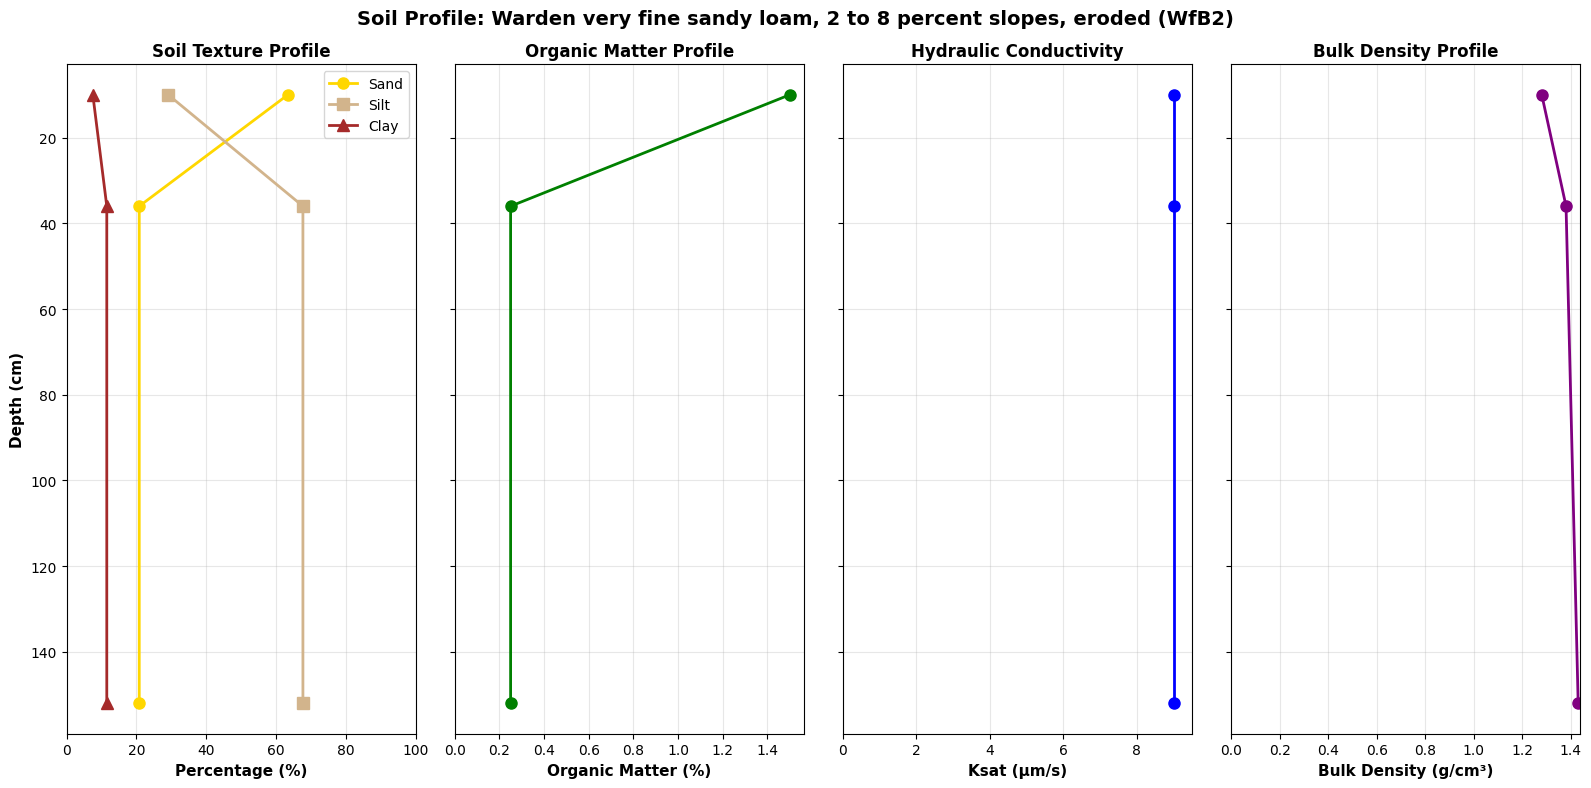

    mukey                                             muname musym     cokey  \
9   69619  Warden very fine sandy loam, 2 to 8 percent sl...  WfB2  26545471   
10  69619  Warden very fine sandy loam, 2 to 8 percent sl...  WfB2  26545471   
11  69619  Warden very fine sandy loam, 2 to 8 percent sl...  WfB2  26545471   

   compname majcompflag    drainagecl comppct_r muacres corestrictkey  ...  \
9    Warden         Yes  Well drained       100    4464          None  ...   
10   Warden         Yes  Well drained       100    4464          None  ...   
11   Warden         Yes  Well drained       100    4464          None  ...   

   hzdepb_r wfifteenbar_r wthirdbar_r wsatiated_r ksat_r dbthirdbar_r  om_r  \
9        10           5.6          15          47      9         1.28   1.5   
10       36           6.6        22.1          44      9         1.38  0.25   
11      152           6.8        22.3          42      9         1.43  0.25   

   sandtotal_r silttotal_r claytotal_r  
9       

In [78]:
df_soil = xml_to_dataframe(get_soil_data_for_polygon(wkt_polygon))
plot_depth_profiles(df_soil, map_unit_key=69619)

# Display all results for target map unit
print(df_soil[df_soil['mukey'] == '69619'])